# L4: Support Data Insight Analysis

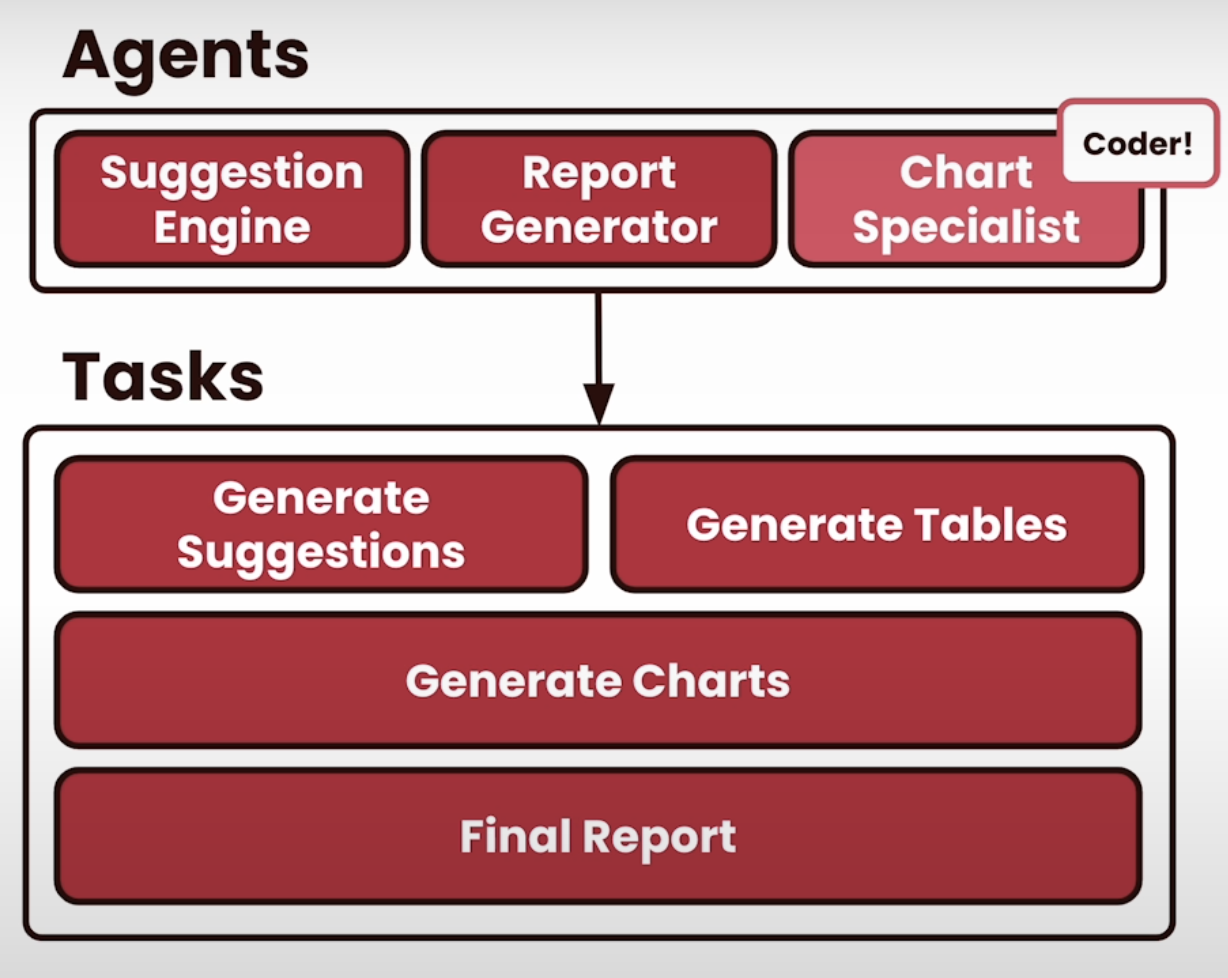

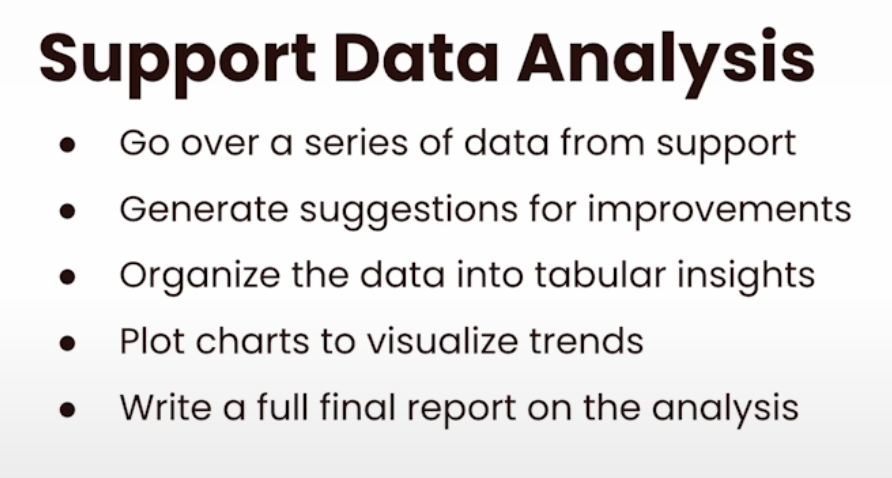

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

## Initial Imports

In [7]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

# Load environment variables
from helper import load_env
load_env()

import os
import yaml
from crewai import Agent, Task, Crew

<p style="background-color:#fff6ff; padding:15px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px"> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>. For more help, please see the <em>"Appendix - Tips and Help"</em> Lesson.</p>

## Loading Tasks and Agents YAML files

In [8]:
# Define file paths for YAML configurations
files = {
    'agents': 'config/agents.yaml',
    'tasks': 'config/tasks.yaml'
}

# Load configurations from YAML files
configs = {}
for config_type, file_path in files.items():
    with open(file_path, 'r') as file:
        configs[config_type] = yaml.safe_load(file)

# Assign loaded configurations to specific variables
agents_config = configs['agents']
tasks_config = configs['tasks']

## Using FileReadTool

In [9]:
from crewai_tools import FileReadTool
csv_tool = FileReadTool(file_path='./support_tickets_data.csv')

## Creating Agents, Tasks and Crew

In [10]:
# Creating Agents
suggestion_generation_agent = Agent(
  config=agents_config['suggestion_generation_agent'],
  tools=[csv_tool]
)

reporting_agent = Agent(
  config=agents_config['reporting_agent'],
  tools=[csv_tool]
)

chart_generation_agent = Agent(
  config=agents_config['chart_generation_agent'],
  allow_code_execution=False
)

# Creating Tasks
suggestion_generation = Task(
  config=tasks_config['suggestion_generation'],
  agent=suggestion_generation_agent
)

table_generation = Task(
  config=tasks_config['table_generation'],
  agent=reporting_agent
)

chart_generation = Task(
  config=tasks_config['chart_generation'],
  agent=chart_generation_agent
)

final_report_assembly = Task(
  config=tasks_config['final_report_assembly'],
  agent=reporting_agent,
  context=[suggestion_generation, table_generation, chart_generation]
)


# Creating Crew
support_report_crew = Crew(
  agents=[
    suggestion_generation_agent,
    reporting_agent,
    chart_generation_agent
  ],
  tasks=[
    suggestion_generation,
    table_generation,
    chart_generation,
    final_report_assembly
  ],
  verbose=True
)


2025-02-15 17:53:09,855 - 139876693687168 - __init__.py-__init__:537 - WARNING: Overriding of current TracerProvider is not allowed


## Testing our Crew

In [11]:
support_report_crew.test(n_iterations=1, openai_model_name='gpt-4o')

2025-02-15 17:53:10,112 - 139876693687168 - __init__.py-__init__:537 - WARNING: Overriding of current TracerProvider is not allowed


# Agent: Suggestion Engine
## Task: Generate actionable suggestions for resolving each classified support ticket. The suggestions should be based on: - Issue Type: Tailor suggestions to the specific type of issue reported. - Historical Data: Use historical data such as resolution_time_minutes and
  satisfaction_rating to inform the suggestions.
- Customer Feedback: Incorporate insights from customer_comments to
  customize the suggestions further.

The goal is to provide clear, actionable steps that the support team can take to resolve each issue efficiently and effectively.



# Agent: Suggestion Engine
## Using tool: Read a file's content
## Tool Input: 
"{\"file_path\": \"./support_tickets_data.csv\"}"
## Tool Output: 
ticket_id,customer_id,issue_type,issue_description,priority,date_submitted,response_time_minutes,resolution_time_minutes,satisfaction_rating,customer_comments,agent_id,resolved
T0001,C0511,API Issue,I'm pleased with how my issue was handled. Thanks!,High,2023-03-25,24



# Agent: Report Generator
## Final Answer: 
### Issue Classification Results

| Issue Type           | Frequency | Priority Levels |
|----------------------|-----------|------------------|
| API Issue            | 6         | High: 5, Medium: 1 |
| Login Issue          | 6         | Critical: 2, Low: 4 |
| Report Generation     | 5         | High: 2, Low: 3 |
| Data Import          | 10        | High: 4, Medium: 6 |
| Feature Request      | 6         | Critical: 1, High: 4, Medium: 1 |
| Billing Issue        | 10        | Critical: 2, High: 4, Medium: 4 |
| UI Bugs              | 6         | Critical: 1, High: 2, Medium: 3 |

### Agent Performance

| Agent ID | Total Tickets | Avg. Resolution Time (minutes) | Avg. Satisfaction Rating |
|----------|---------------|--------------------------------|--------------------------|
| A001     | 8             | 441                            | 2.5                      |
| A002     | 9             | 509                            | 3.0         



# Agent: Report Generator
## Final Answer: 
### Comprehensive Final Report

#### Issue Classification Results
| Issue Type           | Frequency | Priority Levels                 |
|----------------------|-----------|----------------------------------|
| API Issue            | 6         | High: 5, Medium: 1             |
| Login Issue          | 6         | Critical: 2, Low: 4            |
| Report Generation     | 5         | High: 2, Low: 3                 |
| Data Import          | 10        | High: 4, Medium: 6             |
| Feature Request      | 6         | Critical: 1, High: 4, Medium: 1 |
| Billing Issue        | 10        | Critical: 2, High: 4, Medium: 4 |
| UI Bugs              | 6         | Critical: 1, High: 2, Medium: 3 |

![Issue Distribution](./issue_distribution.png)  
![Priority Levels](./priority_levels.png)  

---

#### Agent Performance
| Agent ID | Total Tickets | Avg. Resolution Time (minutes) | Avg. Satisfaction Rating |
|----------|---------------|---------

                             Tasks Scores                              
                        (1-10 Higher is better)                        
┏━━━━━━━━━━━━━━━━━━━━┯━━━━━━━┯━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━┯━━┯━━┓
┃ Tasks/Crew/Agents  │ Run 1 │ Avg. Total │ Agents              │  │  ┃
┠────────────────────┼───────┼────────────┼─────────────────────┼──┼──┨
┃ Task 1             │  8.5  │    8.5     │ - Suggestion Engine │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 2             │  8.5  │    8.5     │ - Report Generator  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 3             │  9.5  │    9.5     │ - Chart Specialist  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 4             │  8.5  │    8.5     │ - Report Generator  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Crew               │ 8.75  │    8.8     │                     │  │  ┃
┃ Execution Time (s) │   0   │     0      │                     │  │  ┃
┗━━━━━━━━━━━━━━━━━━━━┷━━━━━━━┷━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━┷━━┷━━┛

## Training your crew and agents

In [12]:
support_report_crew.train(n_iterations=1, filename='training.pkl')

2025-02-15 17:53:10,618 - 139876693687168 - __init__.py-__init__:537 - WARNING: Overriding of current TracerProvider is not allowed


# Agent: Suggestion Engine
## Task: Generate actionable suggestions for resolving each classified support ticket. The suggestions should be based on: - Issue Type: Tailor suggestions to the specific type of issue reported. - Historical Data: Use historical data such as resolution_time_minutes and
  satisfaction_rating to inform the suggestions.
- Customer Feedback: Incorporate insights from customer_comments to
  customize the suggestions further.

The goal is to provide clear, actionable steps that the support team can take to resolve each issue efficiently and effectively.



# Agent: Suggestion Engine
## Using tool: Read a file's content
## Tool Input: 
"{\"file_path\": \"./support_tickets_data.csv\"}"
## Tool Output: 
ticket_id,customer_id,issue_type,issue_description,priority,date_submitted,response_time_minutes,resolution_time_minutes,satisfaction_rating,customer_comments,agent_id,resolved
T0001,C0511,API Issue,I'm pleased with how my issue was handled. Thanks!,High,2023-03-25,24


 
Processing training feedback.



# Agent: Suggestion Engine
## Final Answer: 
1. **API Issues**
   - Tickets: T0001, T0009, T0021, T0046
     - Suggestions: 
       - Conduct regular training sessions on API functionalities for agents and customer education sessions.
       - Implement a proactive monitoring system to alert the team of API downtimes.
       - Create a feedback form specifically for API issues so users can highlight their concerns easily.
       - Ensure transparency by providing updates to customers on ongoing API improvements and resolutions.

2. **Login Issues**
   - Tickets: T0002, T008, T0014, T0029
     - Suggestions:
       - Perform a thorough audit of the login system to identify common points of failure.
       - Develop an extensive FAQ section addressing login problems, which customers can access easily.
       - Create a step-by-step troubleshooting guide for agents to provide immediate solutions during customer interactions.
       - Provide timely upda



# Agent: Report Generator
## Final Answer: 
### Issue Classification Results

| Issue Type           | Frequency | Priority Level      |
|----------------------|-----------|---------------------|
| API Issue            | 7         | High, Medium, Critical |
| Login Issue          | 7         | Low, Medium, High, Critical |
| Report Generation     | 7         | Low, Medium, High |
| Data Import          | 10        | Low, Medium, High, Critical |
| Feature Request      | 7         | Low, Medium, High, Critical |
| Billing Issue        | 10        | Low, Medium, High, Critical |
| UI Bug               | 5         | Low, Medium, High, Critical |

### Agent Performance

| Agent ID | Total Tickets | Average Response Time (minutes) | Average Resolution Time (minutes) | Average Satisfaction Rating |
|----------|---------------|---------------------------------|------------------------------------|-----------------------------|
| A001     | 8             | 147                             | 7



# Agent: Report Generator
## Final Answer: 
### Issue Classification Results

| Issue Type           | Frequency | Priority Level           |
|----------------------|-----------|--------------------------|
| API Issue            | 7         | High, Medium, Critical    |
| Login Issue          | 7         | Low, Medium, High, Critical |
| Report Generation     | 7         | Low, Medium, High        |
| Data Import          | 10        | Low, Medium, High, Critical |
| Feature Request      | 7         | Low, Medium, High, Critical |
| Billing Issue        | 10        | Low, Medium, High, Critical |
| UI Bug               | 5         | Low, Medium, High, Critical |

### Agent Performance

| Agent ID | Total Tickets | Average Response Time (minutes) | Average Resolution Time (minutes) | Average Satisfaction Rating |
|----------|---------------|---------------------------------|------------------------------------|-----------------------------|
| A001     | 8             | 147            

...

quality looks good, please terminate it
 
Processing training feedback.



# Agent: Report Generator
## Using tool: Read a file's content
## Tool Input: 
"{\"file_path\": \"./support_tickets_data.csv\"}"
## Tool Output: 
ticket_id,customer_id,issue_type,issue_description,priority,date_submitted,response_time_minutes,resolution_time_minutes,satisfaction_rating,customer_comments,agent_id,resolved
T0001,C0511,API Issue,I'm pleased with how my issue was handled. Thanks!,High,2023-03-25,240,927,4,I'm pleased with how my issue was handled. Thanks!,A004,True
T0002,C0729,Login Issue,Excellent service! The agent went above and beyond.,Low,2023-04-06,223,534,5,The problem still persists. Not resolved yet.,A004,False
T0003,C0439,Report Generation,Resolution was satisfactory but could be improved.,Low,2023-04-25,214,592,1,"The issue was escalated quickly, which was appreciated.",A004,False
T0004,C0100,Data Import,Agent was very helpful and polite. Great service!,High,2023-02-20,110,864,2,The issue



# Agent: Report Generator
## Using tool: Read a file's content
## Tool Input: 
"{\"file_path\": \"./support_tickets_data.csv\"}"
## Tool Output: 
ticket_id,customer_id,issue_type,issue_description,priority,date_submitted,response_time_minutes,resolution_time_minutes,satisfaction_rating,customer_comments,agent_id,resolved
T0001,C0511,API Issue,I'm pleased with how my issue was handled. Thanks!,High,2023-03-25,240,927,4,I'm pleased with how my issue was handled. Thanks!,A004,True
T0002,C0729,Login Issue,Excellent service! The agent went above and beyond.,Low,2023-04-06,223,534,5,The problem still persists. Not resolved yet.,A004,False
T0003,C0439,Report Generation,Resolution was satisfactory but could be improved.,Low,2023-04-25,214,592,1,"The issue was escalated quickly, which was appreciated.",A004,False
T0004,C0100,Data Import,Agent was very helpful and polite. Great service!,High,2023-02-20,110,864,2,The issue was resolved quickly. Very satisfied!,A003,True
T0005,C0258,Feature Requ



# Agent: Report Generator
## Using tool: Read a file's content
## Tool Input: 
"{\"file_path\": \"./support_tickets_data.csv\"}"
## Tool Output: 
ticket_id,customer_id,issue_type,issue_description,priority,date_submitted,response_time_minutes,resolution_time_minutes,satisfaction_rating,customer_comments,agent_id,resolved
T0001,C0511,API Issue,I'm pleased with how my issue was handled. Thanks!,High,2023-03-25,240,927,4,I'm pleased with how my issue was handled. Thanks!,A004,True
T0002,C0729,Login Issue,Excellent service! The agent went above and beyond.,Low,2023-04-06,223,534,5,The problem still persists. Not resolved yet.,A004,False
T0003,C0439,Report Generation,Resolution was satisfactory but could be improved.,Low,2023-04-25,214,592,1,"The issue was escalated quickly, which was appreciated.",A004,False
T0004,C0100,Data Import,Agent was very helpful and polite. Great service!,High,2023-02-20,110,864,2,The issue was resolved quickly. Very satisfied!,A003,True
T0005,C0258,Feature Requ



# Agent: Report Generator
## Final Answer: 
**Final Report on Support System Performance**

---

### 1. Issue Classification Results

| Issue Type           | Frequency | Priority Level           |
|----------------------|-----------|--------------------------|
| API Issue            | 7         | High, Medium, Critical    |
| Login Issue          | 7         | Low, Medium, High, Critical |
| Report Generation     | 7         | Low, Medium, High        |
| Data Import          | 10        | Low, Medium, High, Critical |
| Feature Request      | 7         | Low, Medium, High, Critical |
| Billing Issue        | 10        | Low, Medium, High, Critical |
| UI Bug               | 5         | Low, Medium, High, Critical |

![Issue Distribution Chart](issue_distribution_chart.png)

![Priority Levels Chart](priority_levels_chart.png)

---

### 2. Agent Performance

| Agent ID | Total Tickets | Average Response Time (minutes) | Average Resolution Time (minutes) | Average Satisfaction Rating 

ValueError: Critical training data error: Missing fields (human_feedback) for agent 8569009e-70f0-4a3d-a85f-91ac930132a0 in iteration 0.
This indicates a broken training process. Cannot proceed with evaluation.
Please check your training implementation.

## Comparing new test results

In [13]:
support_report_crew.test(n_iterations=1, openai_model_name='gpt-4o')

2025-02-15 17:57:19,076 - 139876693687168 - __init__.py-__init__:537 - WARNING: Overriding of current TracerProvider is not allowed


# Agent: Suggestion Engine
## Task: Generate actionable suggestions for resolving each classified support ticket. The suggestions should be based on: - Issue Type: Tailor suggestions to the specific type of issue reported. - Historical Data: Use historical data such as resolution_time_minutes and
  satisfaction_rating to inform the suggestions.
- Customer Feedback: Incorporate insights from customer_comments to
  customize the suggestions further.

The goal is to provide clear, actionable steps that the support team can take to resolve each issue efficiently and effectively.



# Agent: Suggestion Engine
## Using tool: Read a file's content
## Tool Input: 
"{\"file_path\": \"./support_tickets_data.csv\"}"
## Tool Output: 
ticket_id,customer_id,issue_type,issue_description,priority,date_submitted,response_time_minutes,resolution_time_minutes,satisfaction_rating,customer_comments,agent_id,resolved
T0001,C0511,API Issue,I'm pleased with how my issue was handled. Thanks!,High,2023-03-25,24



# Agent: Report Generator
## Final Answer: 
### Issue Classification Results

| Issue Type           | Frequency | Priority Levels |
|----------------------|-----------|------------------|
| API Issue            | 6         | High: 5, Medium: 1 |
| Login Issue          | 6         | Critical: 2, Low: 4 |
| Report Generation     | 5         | High: 2, Low: 3 |
| Data Import          | 10        | High: 4, Medium: 6 |
| Feature Request      | 6         | Critical: 1, High: 4, Medium: 1 |
| Billing Issue        | 10        | Critical: 2, High: 4, Medium: 4 |
| UI Bugs              | 6         | Critical: 1, High: 2, Medium: 3 |

### Agent Performance

| Agent ID | Total Tickets | Avg. Resolution Time (minutes) | Avg. Satisfaction Rating |
|----------|---------------|--------------------------------|--------------------------|
| A001     | 8             | 441                            | 2.5                      |
| A002     | 9             | 509                            | 3.0         



# Agent: Report Generator
## Final Answer: 
### Comprehensive Final Report

#### Issue Classification Results
| Issue Type           | Frequency | Priority Levels                 |
|----------------------|-----------|----------------------------------|
| API Issue            | 6         | High: 5, Medium: 1             |
| Login Issue          | 6         | Critical: 2, Low: 4            |
| Report Generation     | 5         | High: 2, Low: 3                 |
| Data Import          | 10        | High: 4, Medium: 6             |
| Feature Request      | 6         | Critical: 1, High: 4, Medium: 1 |
| Billing Issue        | 10        | Critical: 2, High: 4, Medium: 4 |
| UI Bugs              | 6         | Critical: 1, High: 2, Medium: 3 |

![Issue Distribution](./issue_distribution.png)  
![Priority Levels](./priority_levels.png)  

---

#### Agent Performance
| Agent ID | Total Tickets | Avg. Resolution Time (minutes) | Avg. Satisfaction Rating |
|----------|---------------|---------

                             Tasks Scores                              
                        (1-10 Higher is better)                        
┏━━━━━━━━━━━━━━━━━━━━┯━━━━━━━┯━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━┯━━┯━━┓
┃ Tasks/Crew/Agents  │ Run 1 │ Avg. Total │ Agents              │  │  ┃
┠────────────────────┼───────┼────────────┼─────────────────────┼──┼──┨
┃ Task 1             │  8.5  │    8.5     │ - Suggestion Engine │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 2             │  8.5  │    8.5     │ - Report Generator  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 3             │  9.5  │    9.5     │ - Chart Specialist  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Task 4             │  8.5  │    8.5     │ - Report Generator  │  │  ┃
┃                    │       │            │                     │  │  ┃
┃ Crew               │ 8.75  │    8.8     │                     │  │  ┃
┃ Execution Time (s) │   1   │     1      │                     │  │  ┃
┗━━━━━━━━━━━━━━━━━━━━┷━━━━━━━┷━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━┷━━┷━━┛

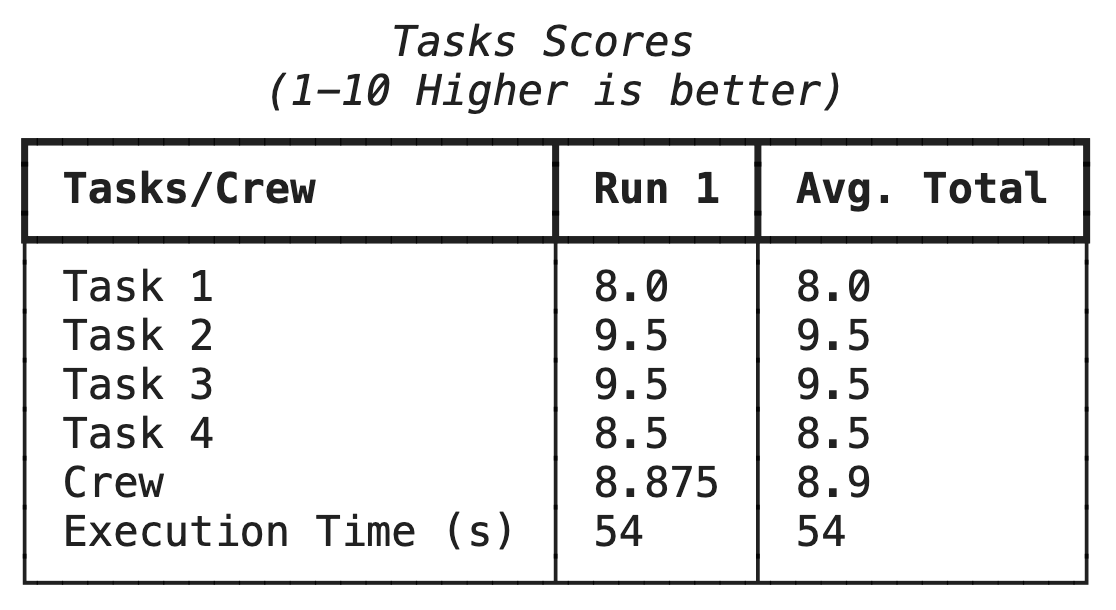

In [14]:
# Display the Trello screenshot
from IPython.display import Image, display

# Load and display the image
test_image = Image(filename='test_before_training.png', width=368)
display(test_image)

## Kicking off Crew

In [15]:
result = support_report_crew.kickoff()

# Agent: Suggestion Engine
## Task: Generate actionable suggestions for resolving each classified support ticket. The suggestions should be based on: - Issue Type: Tailor suggestions to the specific type of issue reported. - Historical Data: Use historical data such as resolution_time_minutes and
  satisfaction_rating to inform the suggestions.
- Customer Feedback: Incorporate insights from customer_comments to
  customize the suggestions further.

The goal is to provide clear, actionable steps that the support team can take to resolve each issue efficiently and effectively.



# Agent: Suggestion Engine
## Using tool: Read a file's content
## Tool Input: 
"{\"file_path\": \"./support_tickets_data.csv\"}"
## Tool Output: 
ticket_id,customer_id,issue_type,issue_description,priority,date_submitted,response_time_minutes,resolution_time_minutes,satisfaction_rating,customer_comments,agent_id,resolved
T0001,C0511,API Issue,I'm pleased with how my issue was handled. Thanks!,High,2023-03-25,24



# Agent: Report Generator
## Final Answer: 
### Issue Classification Results

| Issue Type           | Frequency | Priority Levels |
|----------------------|-----------|------------------|
| API Issue            | 6         | High: 5, Medium: 1 |
| Login Issue          | 6         | Critical: 2, Low: 4 |
| Report Generation     | 5         | High: 2, Low: 3 |
| Data Import          | 10        | High: 4, Medium: 6 |
| Feature Request      | 6         | Critical: 1, High: 4, Medium: 1 |
| Billing Issue        | 10        | Critical: 2, High: 4, Medium: 4 |
| UI Bugs              | 6         | Critical: 1, High: 2, Medium: 3 |

### Agent Performance

| Agent ID | Total Tickets | Avg. Resolution Time (minutes) | Avg. Satisfaction Rating |
|----------|---------------|--------------------------------|--------------------------|
| A001     | 8             | 441                            | 2.5                      |
| A002     | 9             | 509                            | 3.0         

## Result

In [16]:
from IPython.display import display, Markdown
display(Markdown(result.raw))

### Comprehensive Final Report

#### Issue Classification Results
| Issue Type           | Frequency | Priority Levels                 |
|----------------------|-----------|----------------------------------|
| API Issue            | 6         | High: 5, Medium: 1             |
| Login Issue          | 6         | Critical: 2, Low: 4            |
| Report Generation     | 5         | High: 2, Low: 3                 |
| Data Import          | 10        | High: 4, Medium: 6             |
| Feature Request      | 6         | Critical: 1, High: 4, Medium: 1 |
| Billing Issue        | 10        | Critical: 2, High: 4, Medium: 4 |
| UI Bugs              | 6         | Critical: 1, High: 2, Medium: 3 |

![Issue Distribution](./issue_distribution.png)  
![Priority Levels](./priority_levels.png)  

---

#### Agent Performance
| Agent ID | Total Tickets | Avg. Resolution Time (minutes) | Avg. Satisfaction Rating |
|----------|---------------|--------------------------------|--------------------------|
| A001     | 8             | 441                            | 2.5                      |
| A002     | 9             | 509                            | 3.0                      |
| A003     | 9             | 646                            | 2.5                      |
| A004     | 14            | 624                            | 3.1                      |
| A005     | 6             | 575                            | 3.8                      |

![Agent Performance](./agent_performance.png)  

---

#### Customer Satisfaction Over Time
| Month     | Avg. Satisfaction Rating |
|-----------|--------------------------|
| January   | 2.6                      |
| February  | 2.8                      |
| March     | 3.3                      |
| April     | 3.7                      |
| May       | 3.4                      |
| June      | 2.8                      |
| July      | 3.0                      |

![Customer Satisfaction](./customer_satisfaction.png)  

---

### Suggested Actions

1. **API Issues**
   - Investigate recurring API failures and enhance monitoring.
   - Provide additional training for agents on API troubleshooting.
   - Escalate unresolved issues to a senior engineer for deeper analysis.
   - Improve communication about known API issues to customers awaiting responses.

2. **Login Issues**
   - Evaluate server load and optimize login processes.
   - Risk assess the login module for possible bugs causing the failures.
   - Offer a direct channel for customers facing login issues to resolve them quickly.
   - Raise awareness about password resets and recoveries to reduce support tickets.

3. **Report Generation Issues**
   - Simplify the report generation process for users with clear guides.
   - Implement user feedback sessions to understand common pain points.
   - Allocate dedicated support for report-related queries to improve resolution time.
   - Enhance resources for agents on report generation troubleshooting.

4. **Data Import Issues**
   - Create a checklist for common data import issues for agents.
   - Conduct a training session on data validation before import attempts.
   - Establish faster escalation paths for persistent data import issues.
   - Collect customer feedback on the data import process and integrate it into enhancements.

5. **Feature Requests**
   - Set up a calendar for follow-ups on feature requests with customers.
   - Create a feature request form to prioritize requests based on urgency and impact.
   - Engage customers in beta testing phases to gather insights for new features beforehand.
   - Communicate regularly on the status of feature requests to keep customers informed.

6. **Billing Issues**
   - Implement a dedicated billing support hotline for immediate resolutions.
   - Regularly audit billing practices and clarify common points of confusion for users.
   - Train agents on common billing scenarios and necessary solutions.
   - Provide periodic updates on billing issue trends and resolutions with transparency.

7. **UI Bugs**
   - Collaborate with the development team to fix identified UI bugs promptly.
   - Set up a feedback loop with users to catch UI bugs earlier.
   - Increase QA testing before releases to reduce the occurrence of UI bugs.
   - Inform users about ongoing bug fixes and updates related to the UI.

By following these actionable suggestions for each classified support ticket, the support team can streamline their processes and enhance customer satisfaction effectively.